# Mathematical Engineering — Financial Engineering, FY 2025-2026

## Buy Side, Lab 4b — Risk-Based Allocation Strategies

This notebook implements and analyses risk-based allocation strategies on the Euro Stoxx 50 universe with monthly rebalancing and a 2-year rolling estimation window.

**Outline** 

0. Setup & rolling estimators
1. Part I — Equal Risk Contribution (ERC)
2. Part II — Hierarchical Risk Parity (HRP):
   1. Detoning intuition
   2. Cluster stability across rebalances (Rand index)
   3. Sensitivity to clustering choice and to the volatility allocation scheme
3. Part III — Connecting the dots: ERC vs HRP head-to-head and the role of shrinkage


## 0. Setup


In [80]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scipy.cluster.hierarchy as sch
from sklearn.metrics import rand_score

from utilities.backtest import backtest, portfolio_returns
from utilities.covariance_utilities import (
    prepare_rolling_estimation_window,
    covariance_to_correlation,
    risk_contribution,
)
from utilities.hierarchical_clustering import hierarchical_clustering
from utilities.hierarchical_risk_parity import (
    correlation_to_hrp_distance,
    dendrogram_iteration,
    hierarchical_risk_parity,
    recursive_bisection,
)
from utilities.portfolio_optimization import (
    equal_risk_contribution_portfolio,
    inverse_volatility_portfolio,
)
from utilities.principal_component_analysis import (
    detone,
    principal_component_analysis,
)
from utilities.shrinkage import constant_corr_shrinkage, market_factor_shrinkage


In [81]:
# Read prices, compute daily simple returns
last_prices = pd.read_csv("data/sx5e_underlyings.csv", index_col="Date", parse_dates=True
)
performance = last_prices.pct_change().iloc[1:]


In [82]:
# Estimation parameters
estimation_window = 252 * 2  # mistake : 2 years 
min_coverage = 0.95  # asset must have >=95% non-NaN in the window
trading_days = 252 

# Rebalance on the last trading day of each month
rebalance_dates = pd.DatetimeIndex(
    performance.groupby(pd.Grouper(freq="ME"))
    .apply(lambda x: x.index[-1] if len(x) > 0 else None)
    .dropna()
    .values
)


## 1. Pre-computation: rolling covariance estimators

For each rebalance date we estimate three covariance matrices on the trailing 2-year window:

- **sample** — plain `cov()`,
- **constant_corr** — Ledoit–Wolf (2003) constant-correlation shrinkage,
- **mkt_factor** — Ledoit–Wolf (2002) single-factor shrinkage with the
  equally-weighted return of the surviving universe used as the market
  proxy.

The asset universe at every rebalance is restricted to names with
≥95% non-missing observations in the window.


In [83]:
covariances = {}  # date -> {estimator_name: cov_df}
universes = {}  # date -> [tickers]

for rebalance_date in rebalance_dates:
    cur_returns, diag = prepare_rolling_estimation_window(
        returns=performance,
        rebalance_date=rebalance_date,
        lookback=estimation_window,
        min_coverage=min_coverage,
        return_diagnostics=True,
    )
    if diag["row_count"] < estimation_window or cur_returns.shape[1] == 0:
        continue

    reb = rebalance_date.to_pydatetime().date()

    universes[reb] = cur_returns.columns.tolist()  
    covariances[reb] = {
        "sample": cur_returns.cov().to_numpy(),
        "constant_corr": constant_corr_shrinkage(cur_returns)["target"].to_numpy(),
        "mkt_factor": market_factor_shrinkage(cur_returns, cur_returns.iloc[:, -1])["target"].to_numpy(),
    }

all_dates = sorted(covariances.keys())

## Part I — Equal Risk Contribution (ERC)


### 1.b Sanity check: Risk contribution dispersion & IV ≡ ERC under a diagonal Σ


In [84]:
iv_erc_delta = {}
erc_normalized_range = {}

for date in all_dates:
    iv_w  = inverse_volatility_portfolio(covariances[date]["sample"])
    erc_w = equal_risk_contribution_portfolio(covariances[date]["sample"], pcr_tolerance=0.05, options={"maxiter": 5000, "ftol": 1e-15, "disp": False})

    iv_rc  = risk_contribution(iv_w,  covariances[date]["sample"])
    erc_rc = risk_contribution(erc_w, covariances[date]["sample"])
        
    iv_erc_delta[date]        = iv_rc - erc_rc
    erc_normalized_range[date] = (erc_rc.max() - erc_rc.min()) / erc_rc.mean()

# ERC dispersion
erc_ranges = pd.Series(erc_normalized_range)
print("=== ERC Normalized Range (max-min)/mean ===")
print(erc_ranges.describe())

# delta IV - ERC 
delta_df = pd.DataFrame(
    {date: pd.Series(delta, index=universes[date]) 
     for date, delta in iv_erc_delta.items()}
).T  # dates x assets
print("\n=== IV - ERC Risk Contributions (time-averaged) ===")
print(delta_df.mean().describe())

=== ERC Normalized Range (max-min)/mean ===
count    99.000000
mean      0.607105
std       0.223829
min       0.224877
25%       0.422942
50%       0.593805
75%       0.851548
max       0.994385
dtype: float64

=== IV - ERC Risk Contributions (time-averaged) ===
count    50.000000
mean     -0.000239
std       0.002136
min      -0.008759
25%      -0.000779
50%       0.000220
75%       0.000903
max       0.001958
dtype: float64


In [85]:
# Build a diagonal covariance matrix from the sample variances
date = all_dates[0]

S = covariances[date]["sample"]
diag_cov = np.diag(np.diag(S))  # zero out all off-diagonal elements

iv_w_diag  = inverse_volatility_portfolio(diag_cov)
erc_w_diag = equal_risk_contribution_portfolio(diag_cov, pcr_tolerance=0.01)

print(np.allclose(iv_w_diag, erc_w_diag, atol=1e-4))

True


### 1.c ERC backtest across the three covariance estimators


In [86]:
# 1. Compute ERC portfolios for each estimator
erc_portfolios = {"sample": {}, "constant_corr": {}, "mkt_factor": {}}

for reb in all_dates:
    universe = universes[reb]
    for est_name, cov in covariances[reb].items():
        try:
            w = equal_risk_contribution_portfolio(
                cov,
                pcr_tolerance=0.05,
                options={"maxiter": 5000, "ftol": 1e-15, "disp": False},
            )
        except ValueError:
            w = equal_risk_contribution_portfolio(cov, ignore_objective=True)
        erc_portfolios[est_name][reb] = pd.Series(w, index=universe)

# 2. Convert to DataFrames (dates x assets)
erc_weights = {
    est: pd.DataFrame(weights_dict).T  # dates x assets
    for est, weights_dict in erc_portfolios.items()
}

# 3. Backtest using your existing functions
erc_cumrets = {
    est: backtest(erc_weights[est], performance)
    for est in erc_weights
}
erc_returns = {
    est: portfolio_returns(erc_weights[est], performance)
    for est in erc_weights
}

# 4. Metrics
def turnover(weights_df: pd.DataFrame) -> pd.Series:
    """One-way turnover at each rebalance date."""
    return weights_df.diff().abs().sum(axis=1).dropna()

summary = {}
for est in erc_weights:
    ret  = erc_returns[est]
    cum  = erc_cumrets[est]
    dd   = (cum - cum.cummax()) / cum.cummax()
    vol  = ret.ewm(span=63).std() * np.sqrt(252)
    to   = turnover(erc_weights[est])

    summary[est] = {
        "Total Return (%)":  (cum.iloc[-1] - 1) * 100,
        "Avg EWM Vol (%)":   vol.mean() * 100,
        "Max Drawdown (%)":  dd.min() * 100,
        "Avg Turnover (%)":  to.mean() * 100,
    }

print(pd.DataFrame(summary).round(2))

                  sample  constant_corr  mkt_factor
Total Return (%)   94.75          97.11       92.57
Avg EWM Vol (%)    17.41          17.59       17.36
Max Drawdown (%)  -39.50         -39.50      -39.50
Avg Turnover (%)    1.89           1.36        2.26


## Part II — Hierarchical Risk Parity (HRP)


### 2.a Detoning — intuition


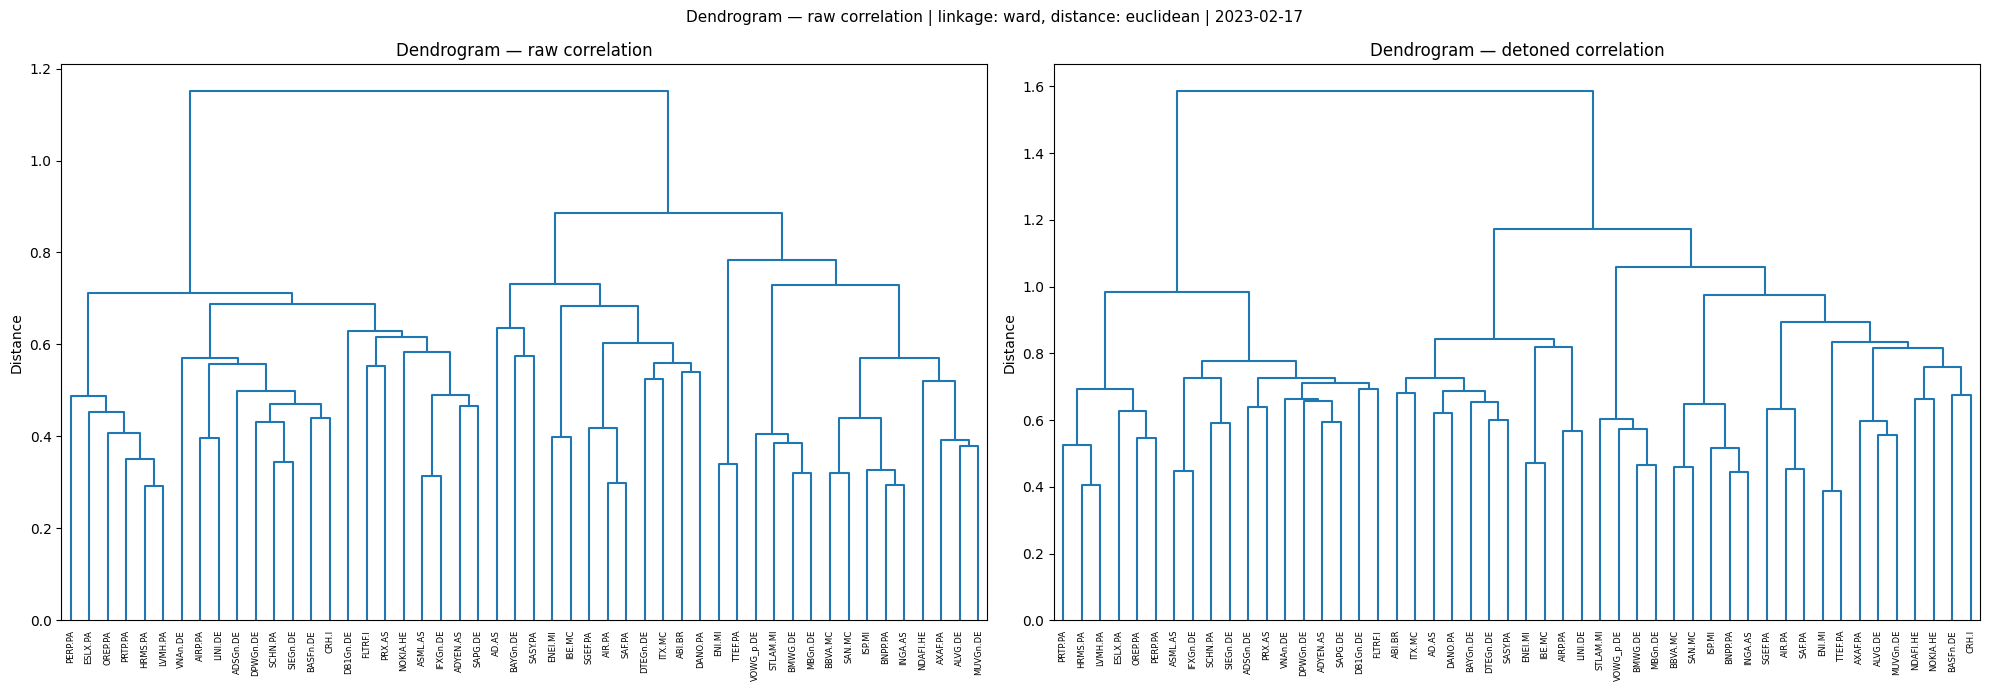

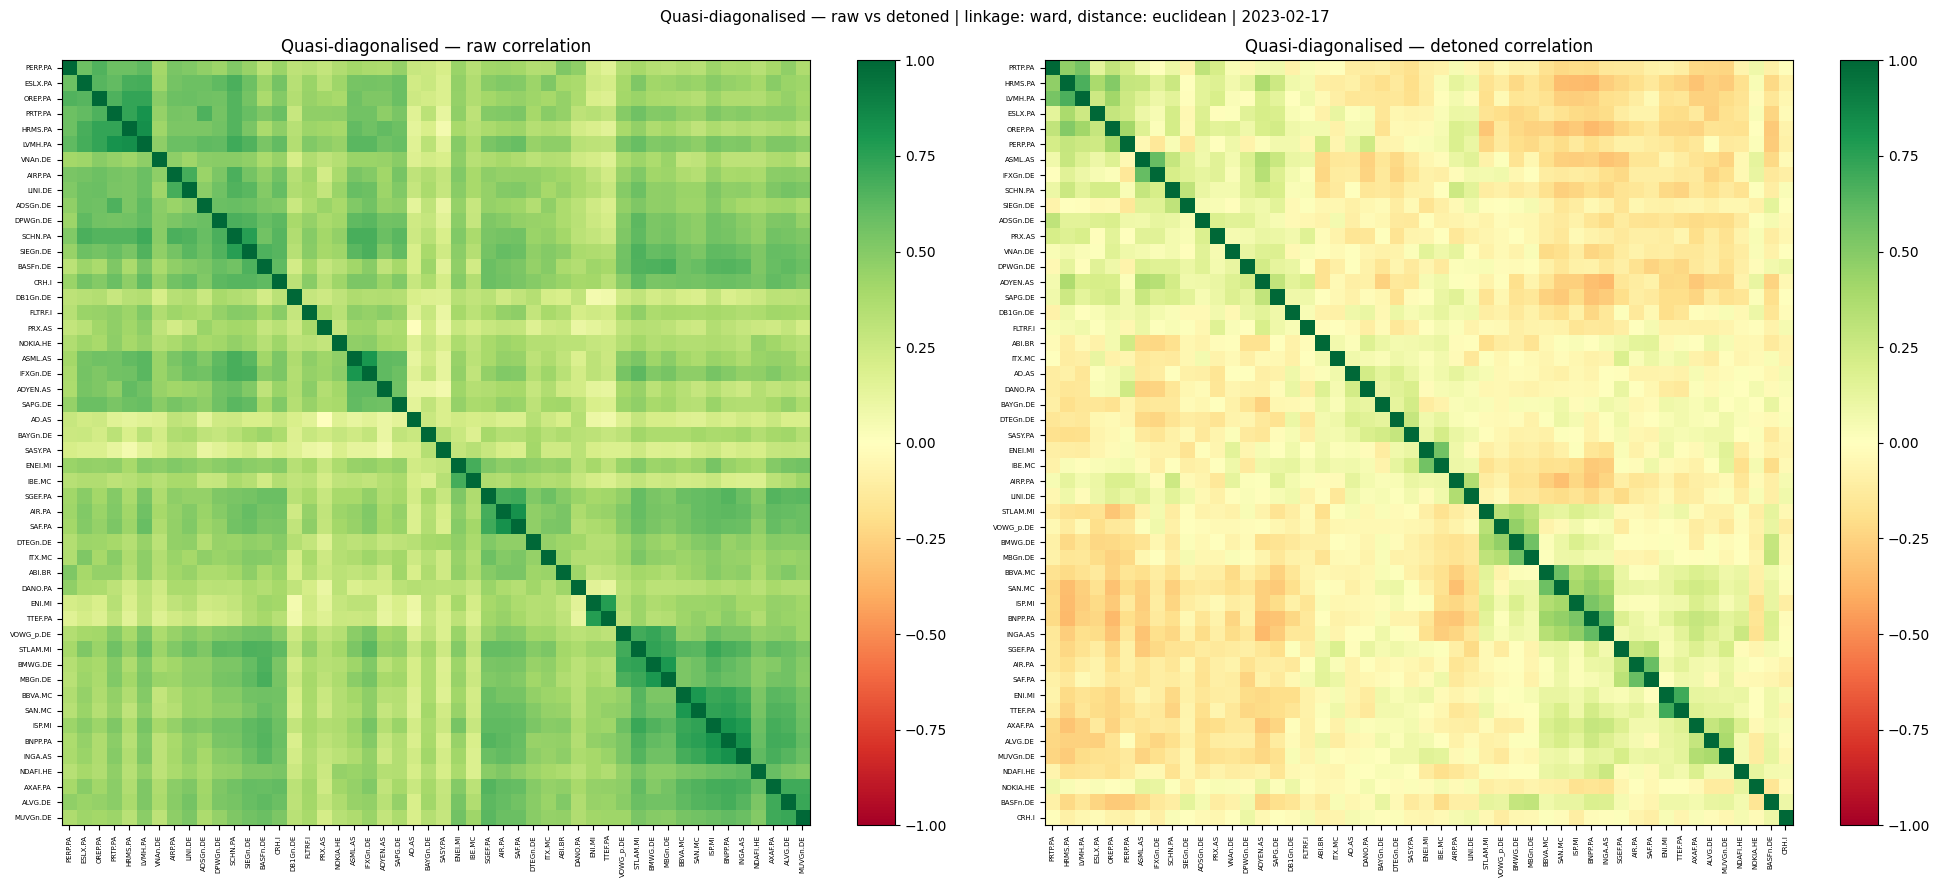

In [87]:
covariances = {
    reb: {
        "sample": pd.DataFrame(covariances[reb]["sample"], index=universes[reb], columns=universes[reb]),
        "constant_corr": pd.DataFrame(covariances[reb]["constant_corr"], index=universes[reb], columns=universes[reb]),
        "mkt_factor": pd.DataFrame(covariances[reb]["mkt_factor"], index=universes[reb], columns=universes[reb]),
    }
    for reb in all_dates
}
last_date = all_dates[-1]  # We work on the last available rebalance date

# Retrieve the sample covariance for the last rebalance date and convert it to a correlation matrix using the utility function.
last_cov = covariances[last_date]["sample"]
last_corr = covariance_to_correlation(last_cov)

last_corr_detoned = detone(corr_matrix=last_corr, components_num=1)
# DETONING
# Removes the rank-1 market component and rescales the diagonal back to 1, so that the remaining structure reflects purely sectoral / idiosyncratic relationships.
last_corr_detoned = detone(corr_matrix=last_corr, components_num=1)

tickers = universes[last_date]

# Wrap both correlation matrices in DataFrames to carry ticker labels through the pipeline (covariance_to_correlation and detone lose them)
last_corr_df         = pd.DataFrame(last_corr,         index=last_cov.index, columns=last_cov.columns)
last_corr_detoned_df = pd.DataFrame(last_corr_detoned, index=last_cov.index, columns=last_cov.columns)

# Build linkage matrices 
# Convert each correlation matrix to the HRP distance, then run Ward hierarchical clustering. Build both raw and detoned
dist_raw     = correlation_to_hrp_distance(last_corr)
dist_detoned = correlation_to_hrp_distance(last_corr_detoned)

link_raw = hierarchical_clustering(
    matrix=pd.DataFrame(dist_raw,     index=last_cov.index, columns=last_cov.columns),
    linkage_method="ward",
    distance_metric="euclidean",
)
link_detoned = hierarchical_clustering(
    matrix=pd.DataFrame(dist_detoned, index=last_cov.index, columns=last_cov.columns),
    linkage_method="ward",
    distance_metric="euclidean",
)

# QUASI-DIAGONALISATION
# Reorder the correlation matrix following the dendrogram leaf order so that highly correlated assets appear close to the diagonal, revealing the
# block structure visually.
leaf_order_raw     = sch.leaves_list(link_raw.values)
leaf_order_detoned = sch.leaves_list(link_detoned.values)

quasi_diag_raw     = last_corr_df.iloc[leaf_order_raw,     leaf_order_raw]
quasi_diag_detoned = last_corr_detoned_df.iloc[leaf_order_detoned, leaf_order_detoned]

# --- Plot 1: dendrograms -----------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(20, 7))
for ax, link, title in zip(
    axes,
    [link_raw, link_detoned],
    ["Dendrogram — raw correlation", "Dendrogram — detoned correlation"],
):
    sch.dendrogram(
        link.values,
        labels=last_cov.index.tolist(),
        ax=ax,
        color_threshold=0,
        leaf_rotation=90,
        leaf_font_size=6,
    )
    ax.set_title(title)
    ax.set_ylabel("Distance")

fig.suptitle(
    f"Dendrogram — raw correlation | linkage: ward, distance: euclidean | {last_date}",
    fontsize=11,
)
plt.tight_layout()
plt.show()

# --- Plot 2: quasi-diagonalised correlation matrices -------------------------
fig, axes = plt.subplots(1, 2, figsize=(20, 9))
for ax, matrix, title in zip(
    axes,
    [quasi_diag_raw, quasi_diag_detoned],
    ["Quasi-diagonalised — raw correlation", "Quasi-diagonalised — detoned correlation"],
):
    im = ax.imshow(matrix.values, cmap="RdYlGn", vmin=-1, vmax=1, aspect="auto")
    ax.set_xticks(range(len(matrix.columns)))
    ax.set_yticks(range(len(matrix.index)))
    ax.set_xticklabels(matrix.columns, rotation=90, fontsize=5)
    ax.set_yticklabels(matrix.index, fontsize=5)
    ax.set_title(title)
    plt.colorbar(im, ax=ax)

fig.suptitle(
    f"Quasi-diagonalised — raw vs detoned | linkage: ward, distance: euclidean | {last_date}",
    fontsize=11,
)
plt.tight_layout()
plt.show()

### 2.c Cluster stability across rebalances (Rand index)

We measure how stable the clustering is between consecutive rebalances via the Rand index. A value close to 1 means the partition into $k$ clusters changes little month-to-month.


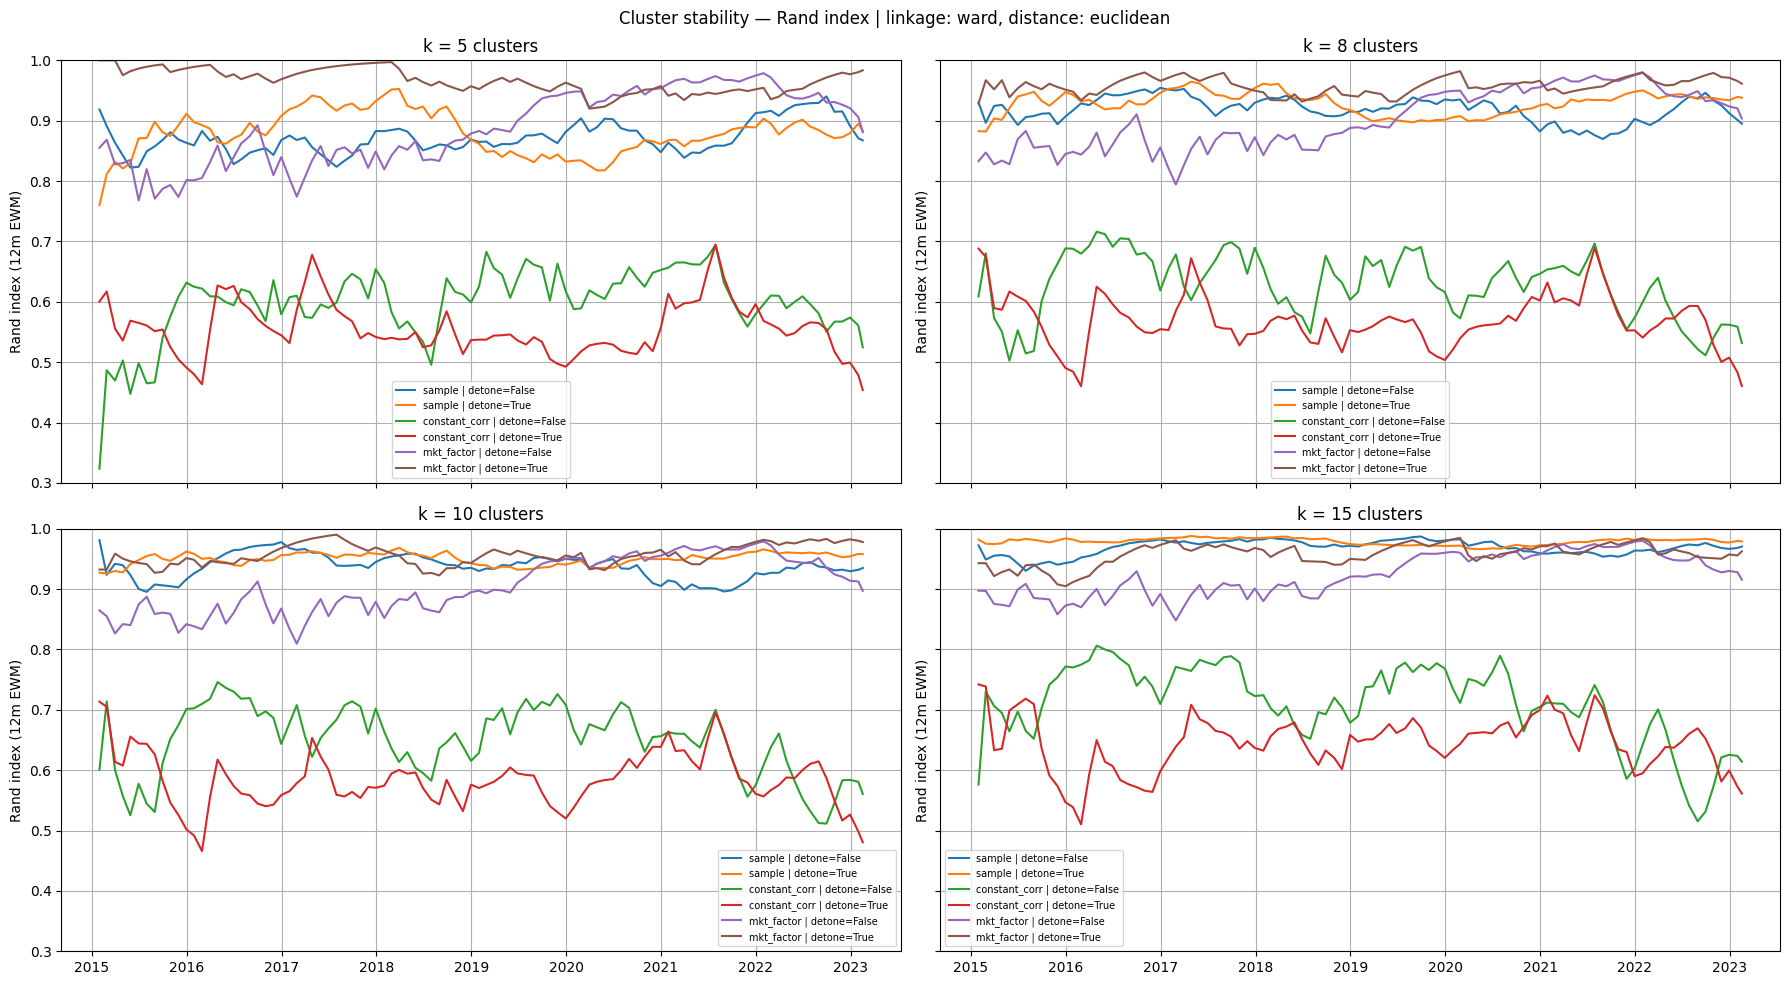

In [ ]:
LINKAGE_METHOD = "ward"
DIST_METRIC = "euclidean"
N_CLUSTERS_GRID = [5, 8, 10, 15]
N_CLUSTERS_FOCUS = 10
COV_KEYS = ["sample", "constant_corr", "mkt_factor"]
DETONE_KEYS = [False, True]


linkages = {(c, d): {} for c in COV_KEYS for d in DETONE_KEYS}
clusters = {
    (c, d, k): {} for c in COV_KEYS for d in DETONE_KEYS for k in N_CLUSTERS_GRID
}

for reb in all_dates:
    for cov_key in COV_KEYS:
        cov = covariances[reb][cov_key]
        for detone_flag in DETONE_KEYS:
            corr = covariance_to_correlation(cov.values)    #covariance correlation
            if detone_flag:
                corr = detone(corr, components_num=1)       #detoning

            dist = correlation_to_hrp_distance(corr)
            dist_df = pd.DataFrame(dist, index=cov.index, columns=cov.columns)

            link = hierarchical_clustering(                 #linkage matrix
                dist_df,
                linkage_method=LINKAGE_METHOD,
                distance_metric=DIST_METRIC,
            )
            linkages[(cov_key, detone_flag)][reb] = link
            for n_clusters in N_CLUSTERS_GRID:
                clusters[(cov_key, detone_flag, n_clusters)][reb] = pd.Series(
                    sch.cut_tree(link.values, n_clusters=n_clusters).flatten(),
                    index=cov.index,
                )

rand_indices = {
    (c, d, k): {} for c in COV_KEYS for d in DETONE_KEYS for k in N_CLUSTERS_GRID
}

for cov_key in COV_KEYS:
    for detone_flag in DETONE_KEYS:
        for n_clusters in N_CLUSTERS_GRID:
            cluster_series = clusters[(cov_key, detone_flag, n_clusters)]
            dates = sorted(cluster_series.keys())
            for t_prev, t_curr in zip(dates[:-1], dates[1:]):
                labels_prev = cluster_series[t_prev]
                labels_curr = cluster_series[t_curr]
                # compute for assets that are the same for both dates universe could change)
                common = labels_prev.index.intersection(labels_curr.index)
                rand_indices[(cov_key, detone_flag, n_clusters)][t_curr] = rand_score(
                    labels_prev.loc[common],
                    labels_curr.loc[common],
                )

# Convert into Series and smooth with EWM to 12 monthly observations
rand_index_ewm = {
    key: pd.Series(vals).ewm(span=12).mean()
    for key, vals in rand_indices.items()
}

# Plot the 12m EWM smoothed Rand index time series
# One subplot per number of clusters, one line per (cov_key, detone_flag) combination
fig, axes = plt.subplots(2, 2, figsize=(18, 10), sharex=True, sharey=True)

for ax, n_clusters in zip(axes.flatten(), N_CLUSTERS_GRID):
    for cov_key in COV_KEYS:
        for detone_flag in DETONE_KEYS:
            series = rand_index_ewm[(cov_key, detone_flag, n_clusters)]
            label = f"{cov_key} | detone={detone_flag}"
            ax.plot(series.index, series.values, label=label)
    
    ax.set_title(f"k = {n_clusters} clusters")
    ax.set_ylabel("Rand index (12m EWM)")
    ax.set_ylim(0.3, 1)
    ax.legend(fontsize=7)
    ax.grid(True)

fig.suptitle(
    f"Cluster stability — Rand index | linkage: {LINKAGE_METHOD}, distance: {DIST_METRIC}",
    fontsize=12,
)
plt.tight_layout()
plt.show()

### 2.d Sensitivity of HRP weights — clustering vs. allocation traversal


In [89]:
LINK_GRID = ["single", "ward", "complete", "average"]
ALLOC_GRID = {
    "recursive_bisection": recursive_bisection,
    "dendrogram_iteration": dendrogram_iteration,
}

hrp_grid = {}
for cov_key in COV_KEYS:
    for link in LINK_GRID:
        for alloc_name, alloc in ALLOC_GRID.items():
            for d in DETONE_KEYS:
                hrp_grid[(cov_key, link, alloc_name, d)] = (
                    None  # !!! COMPLETE AS APPROPRIATE !!!
                )

# !!! COMPLETE AS APPROPRIATE !!!

## Part III — Connecting the Dots


### 3.a ERC vs HRP — Robustness Against Estimator Choice

In [90]:
# !!! COMPLETE AS APPROPRIATE !!!

### 3.b ERC vs HRP — performance, vol, drawdown, turnover


In [91]:
# !!! COMPLETE AS APPROPRIATE !!!